<a href="https://colab.research.google.com/github/nirmalhotakar/AI-HEALTH-ADVISOR/blob/main/Resume_creator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Presented by : **Nirmal Hotakar**

‎ ‎ ‎  ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ 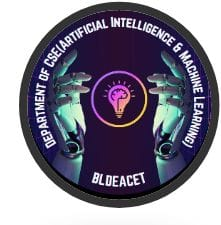

##Under the guidance of : **Sunanda Alur**






In [ ]:
# ⮜ Click the Run button to proceed
# Resume Generator By Nirmal Hotakar
from google.colab import files
import requests

files
def convert_markdown_to_pdf(markdown_content, Resume_file="Resume.pdf", engine="weasyprint"):
    # Define CSS styles for the PDF
    cssfile = """
                body{
                    padding: 0px;
                    margin:0px;
                }
                h1 {
                color: MidnightBlue;
                margin:0px;
                padding:0px;

                }
                h3{
                    color: MidnightBlue;
                    padding-bottom:0px;
                    margin-bottom:0px;
                }
                li{
                    margin-top:5px;
                }

                """
    # API endpoint for converting Markdown to PDF
    url = "https://md-to-pdf.fly.dev"

    # Data to be sent in the POST request
    data = {
        'markdown': markdown_content,
        'css': cssfile,
        'engine': engine
    }

    # Send a POST request to the API
    response = requests.post(url, data=data)

    # Check if the response is successful (status code 200)
    if response.status_code == 200:
        # Save the generated PDF to a file
        with open(Resume_file, 'wb') as f:
            f.write(response.content)
        print(f"PDF saved to {Resume_file}")
    else:
        print(f"Error {response.status_code}: {response.text}")


class Resume:
    def __init__(self, name, email, mobile, education, skills, experience, projects,
                 achievements, activities):
        # Initialize the Resume object with user information
        self.name = name
        self.email = email
        self.mobile = mobile
        self.education = education
        self.skills = skills
        self.experience = experience
        self.projects = projects
        self.achievements = achievements
        self.activities = activities

    def generate_markdown(self):
        # Generate Markdown content for the resume
        markdown_text = f"<h1 style=\"text-align:center;\">{self.name}</h1>\n<p style=\"text-align:center;\">Email: {self.email}| Mobile: {self.mobile} </p>\n\n"
        markdown_text += "### Education\n\n---\n\n"
        # Add education details to the Markdown content
        for edu in self.education:
            markdown_text += f"- {edu['level']}: {edu['institution']} | {edu['field']} | Score: {edu['score']} | {edu['duration']}." + "\n\n"

        markdown_text += "### Skills\n\n---\n\n"
        # Add skills to the Markdown content
        markdown_text += f"{self.skills} \n\n"

        markdown_text += "### Experience\n\n---\n\n"
        # Add work experience details to the Markdown content
        for exp in self.experience:
            markdown_text += f"- **{exp['job_role']}({exp['company_name']})**: {exp['description']}\n"

        markdown_text += "\n### Projects\n\n---\n\n"
        # Add project details to the Markdown content
        for proj in self.projects:
            markdown_text += f"- **{proj['name']}**: {proj['description']}\n"

        markdown_text += "\n### Achievements\n\n---\n\n"
        # Add achievement details to the Markdown content
        for ach in self.achievements:
            markdown_text += f"- {ach}\n"

        markdown_text += "\n### Other Activities\n\n---\n\n"
        # Add other activities to the Markdown content
        markdown_text += self.activities + '\n'

        return markdown_text


def get_user_input():
    # Gather user input for creating the resume
    name = input("Enter your name: ")
    email = input("Enter your email: ")
    mobile = input("Enter your mobile number: ")

    print("\nEducation:")
    education = []
    while True:
        # Prompt user to add education details
        edu_input = input(
            "Do you want to add education details? (yes/no): ").lower()
        if edu_input != 'yes':
            break
        level = input(
            "Enter education level (e.g., Graduation(UG/PG), High School,PUC): ")
        institution = input(f"Enter the name of the {level} institution: ")
        field = input(f"Enter the field of study at {institution}: ")
        duration = input(f"Enter passing year of {level} at {institution}: ")
        score = input(
            f"Enter your score (e.g., GPA/Percentage) of {level} at {institution}: ")
        education.append({"level": level, "institution": institution,
                          "field": field, "duration": duration, "score": score, })

    skills = input("\nEnter your skills (comma-separated): ")

    print("\nExperience:")
    experience = []
    while True:
        # Prompt user to add work experience details
        job_role = input("Enter your job role (or type 'done' to finish): ")
        if job_role.lower() == 'done':
            break
        exp_company_name = input("Enter the company name: ")
        exp_description = input(f"Enter the description for '{job_role}': ")
        experience.append(
            {"job_role": job_role, "company_name": exp_company_name,
             "description": exp_description})

    print("\nProjects:")
    projects = []
    while True:
        # Prompt user to add project details
        proj_heading = input(
            "Enter the project Title (or type 'done' to finish): ")
        if proj_heading.lower() == 'done':
            break
        proj_description = input(
            f"Enter the description for '{proj_heading}': ")
        projects.append(
            {"name": proj_heading, "description": proj_description})

    print("\nAchievements:")
    achievements = []
    while True:
        # Prompt user to add achievement details
        ach_input = input(
            "Enter an achievement detail (or type 'done' to finish): ")
        if ach_input.lower() == 'done':
            break
        achievements.append(ach_input)

    print("\nOther Activities like hobbies:")
    # Prompt user to add other activities or hobbies
    activities = input("Enter your other activities: ")
    return Resume(name, email, mobile, education, skills,
                  experience, projects, achievements, activities)


if __name__ == "__main__":
    # Main execution block
    user_resume = get_user_input()
    markdown_text = user_resume.generate_markdown()
    convert_markdown_to_pdf(markdown_text)
    files.download('Resume.pdf')
    time.sleep(1.0)

Enter your name: Ssrr
Enter your email: Dsdd
Enter your mobile number: Ssdd

Education:
Do you want to add education details? (yes/no): No

Enter your skills (comma-separated): Nggf

Experience:
Enter your job role (or type 'done' to finish): Done

Projects:
Enter the project Title (or type 'done' to finish): Done

Achievements:
Enter an achievement detail (or type 'done' to finish): Done

Other Activities like hobbies:
Enter your other activities: Fsf
PDF saved to Resume.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

NameError: name 'time' is not defined

# ************************ *Thank You* ************************